# The Decay Chain of $^{220}$Radon:  a simple Monte Carlo

The decay chain of Radon is shown below


(The $\beta$'s are actually $\beta^-$ and not $\beta^+$.)

If we start with a number of radon atoms N, in a closed environment, what is the time evolution of each of the subsequent species?

We can and will integrate the time evolution with a set of coupled differential equations and use solve_ivp.  But setting the problem up in MC gives us several advantages:

1.  Once we have the framework in place, we can answer a very broad range of questions- like "what is the time distribution during which the system has one (or any other number we care to pick) Thallium atoms?" 
2.  It enables us to test statistics in a rigorous manner; and doing statistical tests within a MC framework is simple.
3.  It allows us to simply change the initial conditions.  
4.  For large dimensional problems, or problems with complex boundary conditions, MC is often much easier than multidimensional integration.

The way we write the MonteCarlo is to follow the history of each particle.  In principle we can't do it- because we can't predict when any particular atom will decay- but we can generate an equivalent history for each atom.  

Let's start by throwing the time a particular Radon atom will decay.  The halflife of radon is 55 seconds, and the probability that a radon decays in an interval of time $dt$ is a constant- $\lambda dt$.  We define $P(t)$ as the probability a radon survives to time $t$. Then the probability it survives to $t+dt$ is the probability it survives to $t$ times the probability it doesn't decay in time dt:
\begin{equation}dP(t+dt)=P(t)(1-\lambda dt)\rightarrow \frac{dP}{dt}=-P\lambda\rightarrow P=P_0 e^{-\lambda t}\end{equation}

We set $P_0$ by requiring the integrated probabilty distribution to be 1:
\begin{equation}1=\int_0^\infty P_0 e^{-\lambda t}=\frac{P_0}{\lambda}\end{equation}

and we find $\lambda$ because the ''half-life'' is the time at which probability of survival is 1/2:
\begin{equation}\frac{P_0}{2}=P_0 e^{-\lambda t_{1/2}}\rightarrow \lambda=\frac{log(2)}{t_{1/2}}\end{equation}

so in the end we have

\begin{equation}P(t)=\lambda e^{-\lambda t}\end{equation}

Note that half-lives are used in nuclear physics.  In particle physics and atomic physics decay rates $1/\lambda$ are typically used.  Most computer programs follow the "log means natural log" convention.  

Let's start by plotting the lifetime distribution of a radon:

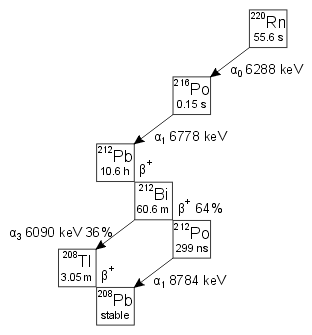

## Histograms and distributions

When we start using probability distributions, we are naturally led to *histograms*-- where the bins show the fraction of events in a given range.  It is closely related to probability distributions.  



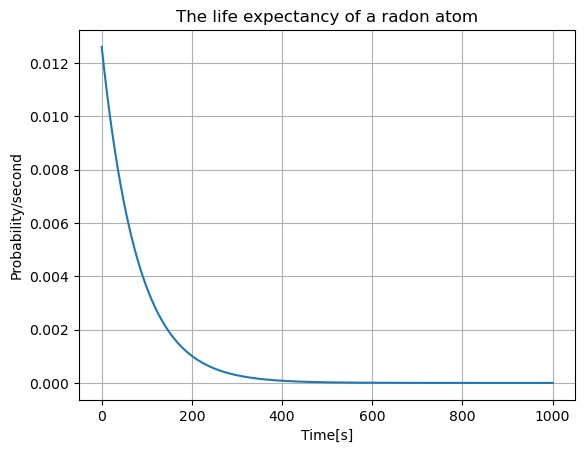

In [2]:
import numpy as np
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('figure',dpi=100)

lambdaRn=np.log(2)/55
plt.title('The life expectancy of a radon atom')
plt.xlabel('Time[s]')
plt.ylabel('Probability/second')
t=np.linspace(0,1000,1000)
p=lambdaRn*np.exp(-lambdaRn*t)
plt.plot(t,p)
plt.grid()
plt.show()



## Histograms and Distributions

To start, we just pick some random numbers from a *uniform* distribution, and see how random numbers vary.  We can run this code several times and get several different distributions.  We will plot both a histogram of the numbers themselves, as well as a histogram of how many random numbers fall within equally sized bins.  

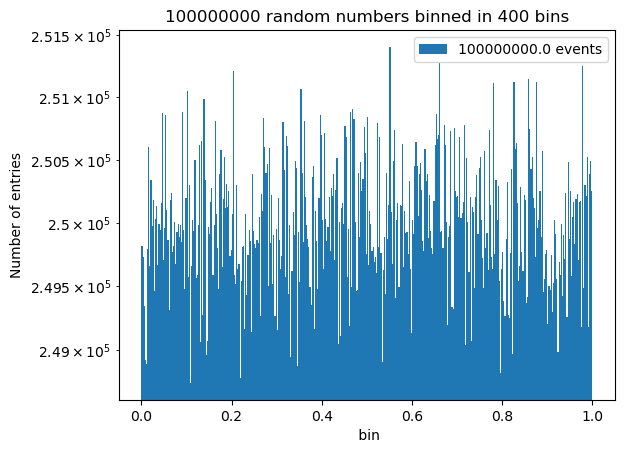

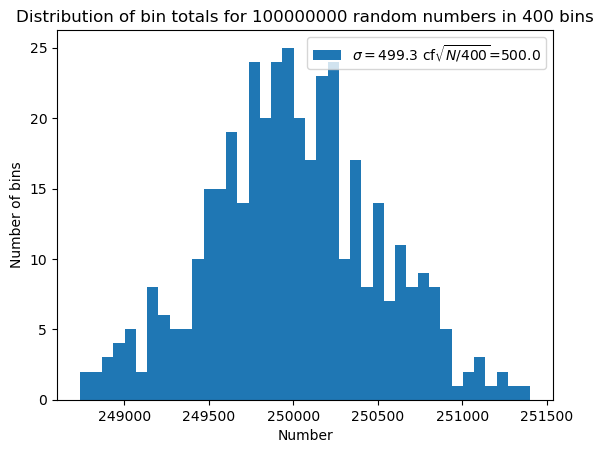

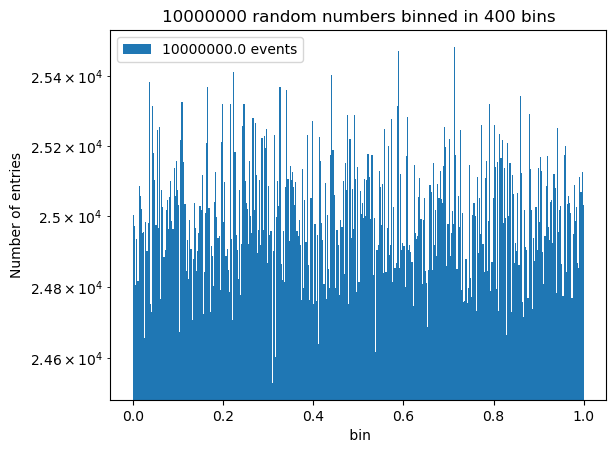

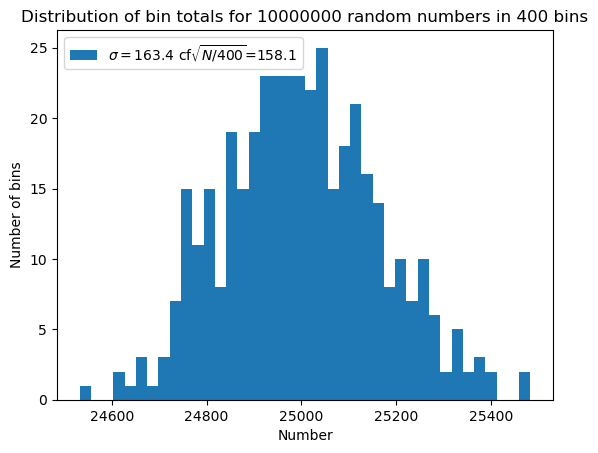

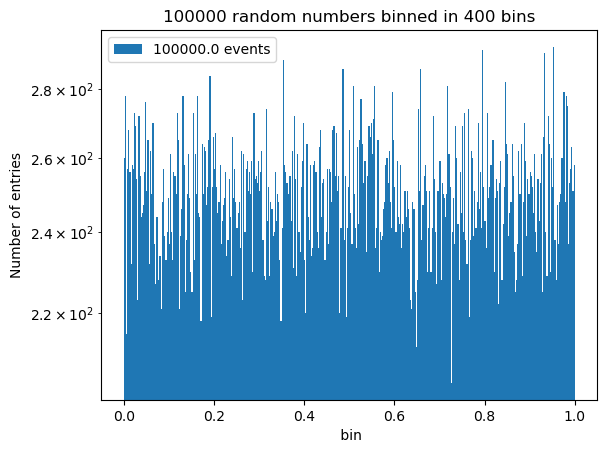

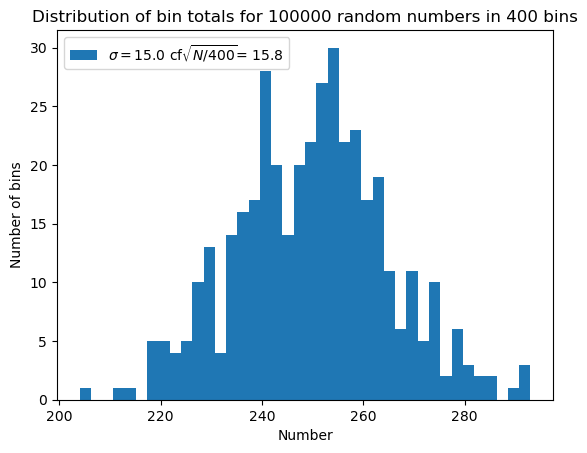

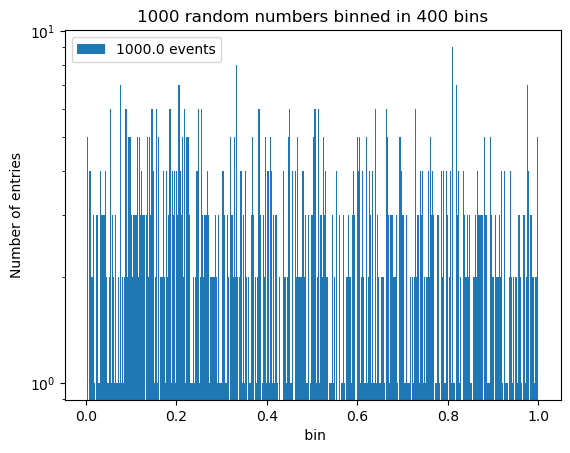

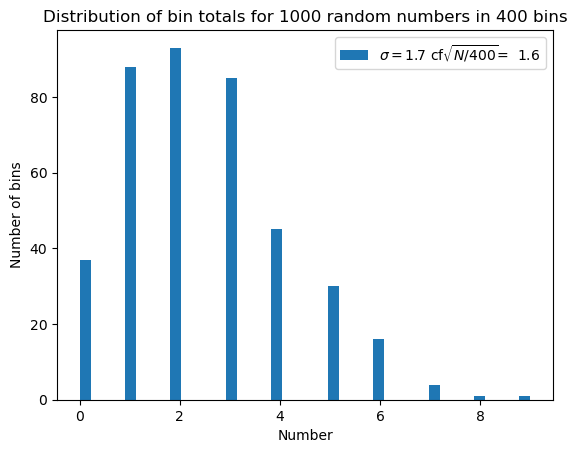

In [3]:
rng=np.random.default_rng()
for N in [1e8,1e7,1e5,1e3]:
    h=rng.random(int(N))
    hh,b,c=plt.hist(h,400,label=f'{N} events')
    plt.title(f'{int(N)} random numbers binned in 400 bins')
    plt.xlabel(' bin')
    plt.ylabel('Number of entries')
    plt.yscale('log')
    plt.legend()
    plt.show()
    plt.hist(hh,40,label=f'$\sigma={np.std(hh):5.1f}$ cf'+'$\sqrt{N/400}$'+f'={np.sqrt(N/400):5.1f}')
    plt.title(f"Distribution of bin totals for {int(N)} random numbers in 400 bins")
    plt.xlabel("Number")
    plt.ylabel("Number of bins")
    plt.legend()
    plt.show()



# Simple (bad) random number generator

In the example above, we used a random number generator, which turns out to be an incredibly important algorithm.  But a computer just does operations like multiply, divide, add, etc.  How does a computer generate a chain of numbers that are not related to each other?  

Below is a simple version- basically one looks at the least significant bits after a multiplication.  This has been rigorously extended and tested with a set of random number generators.  

See the PCG paper in eclass.  And look up RANDU in wikipedia, as well as Diehard tests.  

65536


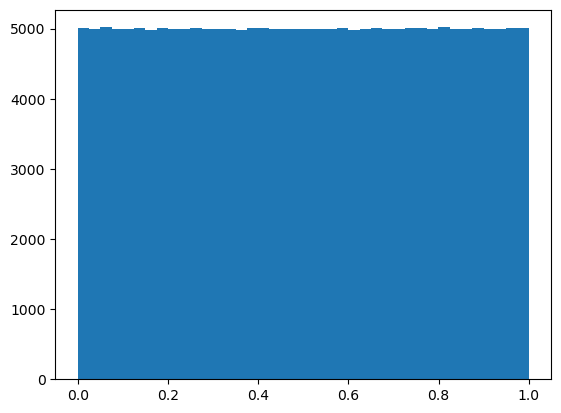

In [4]:
print(2**16)
multiplier=12345
a=6801
state=23456
lran=[]
for i in range(200000):
    state=(multiplier*state+a)%65536
    lran.append(state)
#    print(state)
lran=np.array(lran)/65536.0
plt.hist(lran,40)
plt.show()

In [5]:
np.random.exponential(size=20)

array([0.08131261, 0.77881211, 4.01652182, 0.04664593, 1.6637299 ,
       1.10588249, 0.38814302, 0.35872959, 4.58062009, 0.17623847,
       0.17892118, 0.16375154, 0.93604717, 1.37642595, 1.65805629,
       1.11358618, 1.02768008, 0.14495922, 0.25912039, 2.10781041])

In [6]:
rng=np.random.default_rng(12345)
help(rng)

Help on Generator object:

class Generator(builtins.object)
 |  Generator(bit_generator)
 |  
 |  Container for the BitGenerators.
 |  
 |  ``Generator`` exposes a number of methods for generating random
 |  numbers drawn from a variety of probability distributions. In addition to
 |  the distribution-specific arguments, each method takes a keyword argument
 |  `size` that defaults to ``None``. If `size` is ``None``, then a single
 |  value is generated and returned. If `size` is an integer, then a 1-D
 |  array filled with generated values is returned. If `size` is a tuple,
 |  then an array with that shape is filled and returned.
 |  
 |  The function :func:`numpy.random.default_rng` will instantiate
 |  a `Generator` with numpy's default `BitGenerator`.
 |  
 |  **No Compatibility Guarantee**
 |  
 |  ``Generator`` does not provide a version compatibility guarantee. In
 |  particular, as better algorithms evolve the bit stream may change.
 |  
 |  Parameters
 |  ----------
 |  bit_g

In [7]:
rng.random(10)

array([0.22733602, 0.31675834, 0.79736546, 0.67625467, 0.39110955,
       0.33281393, 0.59830875, 0.18673419, 0.67275604, 0.94180287])

### Throw and test technique for generating a random number distribution
The easiest way to pick events according to this probability distribution is to throw a random time- uniformly between 0 and 1000 s, and then throw a second random number between 0 and lambda.  If the number is less than or equal to the probability distribution, we keep that time; otherwise throw again.  

This is completely analogous to using a random number generator to find pi-- by throwing x and y uniformly between -1 and 1, and then selecting events inside r<=1.  The fraction of events that we select is $f=\frac{\pi r^2}{4 r^2}=\frac {\pi}{4}.$  We will do this first, and then return to generating the radon decay curve.

Do it for 100000 events and plot the time distribution:


In [8]:
help(np.nonzero)

Help on _ArrayFunctionDispatcher in module numpy:

nonzero(a)
    Return the indices of the elements that are non-zero.
    
    Returns a tuple of arrays, one for each dimension of `a`,
    containing the indices of the non-zero elements in that
    dimension. The values in `a` are always tested and returned in
    row-major, C-style order.
    
    To group the indices by element, rather than dimension, use `argwhere`,
    which returns a row for each non-zero element.
    
    .. note::
    
       When called on a zero-d array or scalar, ``nonzero(a)`` is treated
       as ``nonzero(atleast_1d(a))``.
    
       .. deprecated:: 1.17.0
    
          Use `atleast_1d` explicitly if this behavior is deliberate.
    
    Parameters
    ----------
    a : array_like
        Input array.
    
    Returns
    -------
    tuple_of_arrays : tuple
        Indices of elements that are non-zero.
    
    See Also
    --------
    flatnonzero :
        Return indices that are non-zero in the fl

In [9]:
help(rng.random)

Help on built-in function random:

random(...) method of numpy.random._generator.Generator instance
    random(size=None, dtype=np.float64, out=None)
    
    Return random floats in the half-open interval [0.0, 1.0).
    
    Results are from the "continuous uniform" distribution over the
    stated interval.  To sample :math:`Unif[a, b), b > a` use `uniform`
    or multiply the output of `random` by ``(b - a)`` and add ``a``::
    
        (b - a) * random() + a
    
    Parameters
    ----------
    size : int or tuple of ints, optional
        Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
        ``m * n * k`` samples are drawn.  Default is None, in which case a
        single value is returned.
    dtype : dtype, optional
        Desired dtype of the result, only `float64` and `float32` are supported.
        Byteorder must be native. The default value is np.float64.
    out : ndarray, optional
        Alternative output array in which to place the result. If siz

In [10]:
for n in np.logspace(2,8,7):
    d=rng.random(size=(int(n),2))*2-1 #first and second numbers between -1 and 1
    r2=np.sum(d**2,axis=1)
    print(f'For {n} elements thrown, $\pi$={4*len((r2<=1).nonzero()[0])/n}')

print(f"The value of pi from numpy is {np.pi}")

For 100.0 elements thrown, $\pi$=3.04
For 1000.0 elements thrown, $\pi$=3.236
For 10000.0 elements thrown, $\pi$=3.1388
For 100000.0 elements thrown, $\pi$=3.13788
For 1000000.0 elements thrown, $\pi$=3.137532
For 10000000.0 elements thrown, $\pi$=3.1408356
For 100000000.0 elements thrown, $\pi$=3.14134108
The value of pi from numpy is 3.141592653589793


In [11]:
d=rng.random(size=(int(100),2))*2-1
r2=np.sum(d**2,axis=1)
print(r2<=1,'\n', (r2<=1).nonzero())
len((r2<=1).nonzero()[0]),np.sum(r2<=1)

[False  True  True  True  True False  True  True  True  True  True  True
  True  True  True False  True  True  True False  True  True  True  True
  True  True  True  True  True  True  True False  True  True  True False
  True  True  True  True False  True False  True False  True  True  True
 False  True  True  True  True False  True  True  True  True  True False
  True  True  True  True  True False  True  True  True  True  True  True
  True  True  True  True  True  True  True False  True  True  True  True
 False  True False  True False  True  True  True  True  True  True  True
  True  True  True  True] 
 (array([ 1,  2,  3,  4,  6,  7,  8,  9, 10, 11, 12, 13, 14, 16, 17, 18, 20,
       21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 32, 33, 34, 36, 37, 38, 39,
       41, 43, 45, 46, 47, 49, 50, 51, 52, 54, 55, 56, 57, 58, 60, 61, 62,
       63, 64, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 80, 81,
       82, 83, 85, 87, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]),)


(83, 83)

##
Use throw and pick to generate exponential distribution.

In [12]:
d=rng.random(size=(1000000,2))*np.array([1000,lambdaRn]) #throw 1 million pairs of random numbers
#first number is flat from 0-1000 and corresponds to time.  Second number is flat from 0-lambdaRn 
# and is used to decide if we should use the pair or not.  
print(d[:10,:])
tdist=d[ np.asarray(lambdaRn*np.exp(-lambdaRn*d[:,0])>d[:,1]).nonzero(),0].reshape(-1)
print(tdist)
print(tdist.shape)

[[1.17441181e+02 5.56749312e-03]
 [1.95069956e+02 6.85064643e-03]
 [8.59764898e+01 1.08534945e-02]
 [2.29472276e+01 4.40745364e-03]
 [7.26445323e+02 9.02411645e-03]
 [9.61930169e+02 7.17990297e-03]
 [8.57830004e+02 2.32696678e-03]
 [6.48205361e+02 1.25169130e-02]
 [4.63560805e+02 1.20020012e-02]
 [2.93151485e+02 3.72550978e-03]]
[ 22.9472276  132.92323728  12.26329808 ...  14.84162778  79.44792205
 232.58678015]
(79119,)


In [13]:
tdist[:10]

array([ 22.9472276 , 132.92323728,  12.26329808, 182.32361497,
        14.31144234, 158.0395477 , 119.04196168, 106.49940051,
        58.21545615, 187.16481887])

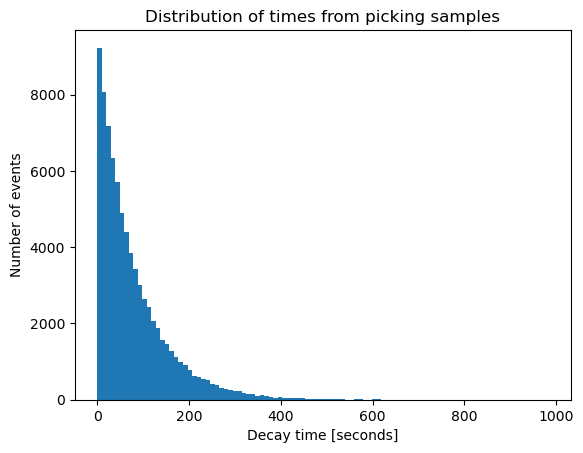

In [14]:
plt.figure()
plt.hist(tdist,100)
plt.title('Distribution of times from picking samples')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.show()


This is not particularly efficient; it also defines a "false" cutoff at 1000 second.  For many distributions (especially if we have nice analytical forms)  we are better off throwing the probability, and then finding the decay time that corresponds to that probability.  So if $R$ is a random number between 0 and 1, we solve the equation:
\begin{equation}\lambda\int_0^t exp^{-\lambda t'}dt'=R\rightarrow t=-\frac{\log(1-R)}{\lambda}\end{equation}

Since R is a random number between 0 and 1, 1-R is also a random number between 0 and 1, and so we don't need to do the subtraction.  
Now generate and histogram 1 million events this way:

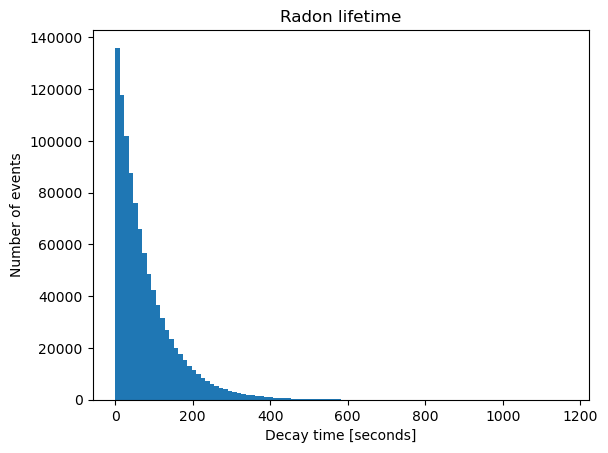

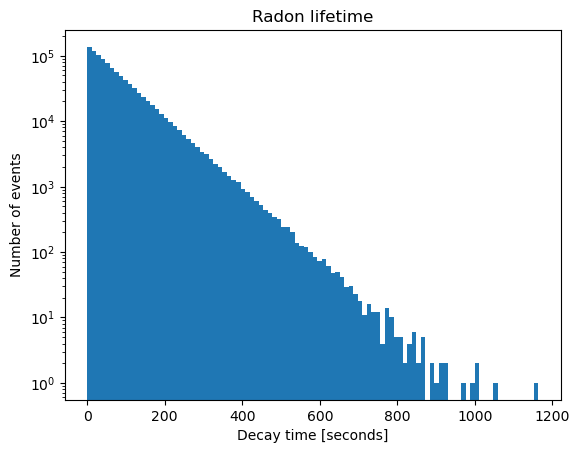

In [15]:
d=np.random.rand(1000000)
t=-np.log(d)/lambdaRn
plt.figure()
plt.hist(t,100)
plt.title('Radon lifetime')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.show()
plt.figure()
plt.yscale('log')
plt.hist(t,100)
plt.title('Radon lifetime')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.show()

It turns out that for common distributions, this technique is already built into numpy.  

In [16]:


help(np.random)

Help on package numpy.random in numpy:

NAME
    numpy.random

DESCRIPTION
    Random Number Generation
    
    Use ``default_rng()`` to create a `Generator` and call its methods.
    
    =============== =========================================================
    Generator
    --------------- ---------------------------------------------------------
    Generator       Class implementing all of the random number distributions
    default_rng     Default constructor for ``Generator``
    =============== =========================================================
    
    ============================================= ===
    BitGenerator Streams that work with Generator
    --------------------------------------------- ---
    MT19937
    PCG64
    PCG64DXSM
    Philox
    SFC64
    ============================================= ===
    
    ============================================= ===
    Getting entropy to initialize a BitGenerator
    --------------------------------------------

In [17]:
help(np.random.exponential)

Help on built-in function exponential:

exponential(...) method of numpy.random.mtrand.RandomState instance
    exponential(scale=1.0, size=None)
    
    Draw samples from an exponential distribution.
    
    Its probability density function is
    
    .. math:: f(x; \frac{1}{\beta}) = \frac{1}{\beta} \exp(-\frac{x}{\beta}),
    
    for ``x > 0`` and 0 elsewhere. :math:`\beta` is the scale parameter,
    which is the inverse of the rate parameter :math:`\lambda = 1/\beta`.
    The rate parameter is an alternative, widely used parameterization
    of the exponential distribution [3]_.
    
    The exponential distribution is a continuous analogue of the
    geometric distribution.  It describes many common situations, such as
    the size of raindrops measured over many rainstorms [1]_, or the time
    between page requests to Wikipedia [2]_.
    
    .. note::
        New code should use the `~numpy.random.Generator.exponential`
        method of a `~numpy.random.Generator` instanc

Now we work through the same example with the built in exponential function:


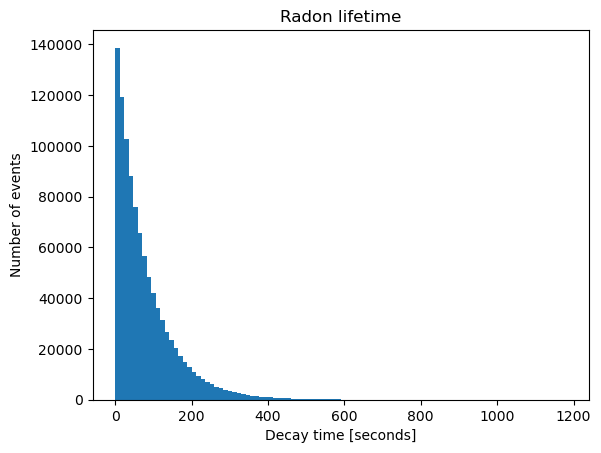

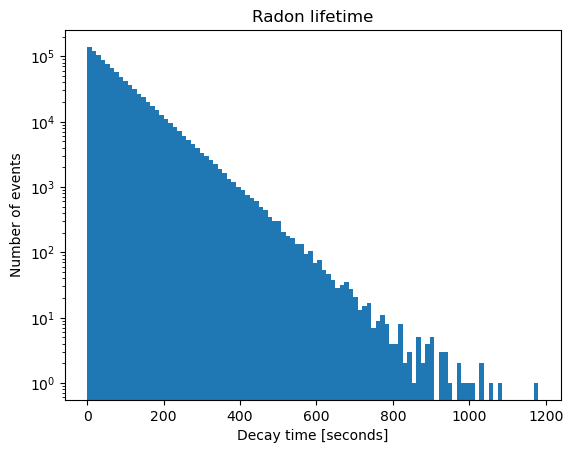

In [18]:
d=rng.exponential(1/lambdaRn,1000000)
plt.figure()
plt.hist(d,100)
plt.title('Radon lifetime')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.show()
plt.figure()
plt.yscale('log')
plt.hist(d,100)
plt.title('Radon lifetime')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.show()

Now we have a simulation of the experiment- where we have 1000000 radon atoms, and, - in our simulation- we know exactly when each one decays.  

Look back at the decay chain- the next element is $^{216}$Po, with a half life of 0.15 seconds.  We generate the decay times for each of those atoms as well.  

$^{212}$Pb has a half life of 10.6 hours followed by $^{212}$Bi with a half life of 60.6 m.  

So let us make arrays that contain the lifetimes for each of the 1000000 atoms.

$^{212}$Bi, with a halflife of 60.6 m, has a branch-- 64% of the time it decays to $^{212}$Po, which has a half life of 299 ns, and 36% of the time it decays to $^{208}$Tl with a halflife of 3.05 m.  Both branches come back to $^{208}$Pb, which is stable. 

Atom 0: Radon 341.3554 s, Po-216 0.5747 s, Pb-212 39526.4407 s, Bi-212  9178.0639s, Po-212 0.0s, Tl-208     7.9335s
Atom 1: Radon  60.0271 s, Po-216 0.0764 s, Pb-212 16925.7397 s, Bi-212  3398.9362s, Po-212 2.564e-08s, Tl-208     0.0000s
Atom 2: Radon  93.8713 s, Po-216 0.0448 s, Pb-212 343511.3857 s, Bi-212  1554.3282s, Po-212 7.051e-07s, Tl-208     0.0000s
Atom 3: Radon 140.8451 s, Po-216 0.6267 s, Pb-212 67099.0161 s, Bi-212  9266.7528s, Po-212 0.0s, Tl-208   473.8344s
Atom 4: Radon 192.0220 s, Po-216 0.0627 s, Pb-212 113309.1264 s, Bi-212  1464.8833s, Po-212 7.17e-07s, Tl-208     0.0000s
Atom 5: Radon  13.9484 s, Po-216 0.4917 s, Pb-212 64857.2039 s, Bi-212 12182.5097s, Po-212 5.019e-07s, Tl-208     0.0000s
Atom 6: Radon  40.8523 s, Po-216 0.1265 s, Pb-212 26648.7567 s, Bi-212  4107.4533s, Po-212 9.157e-07s, Tl-208     0.0000s
Atom 7: Radon  16.8234 s, Po-216 0.0203 s, Pb-212 172830.0321 s, Bi-212  6493.6456s, Po-212 2.492e-07s, Tl-208     0.0000s
Atom 8: Radon 106.1547 s, Po-216 0

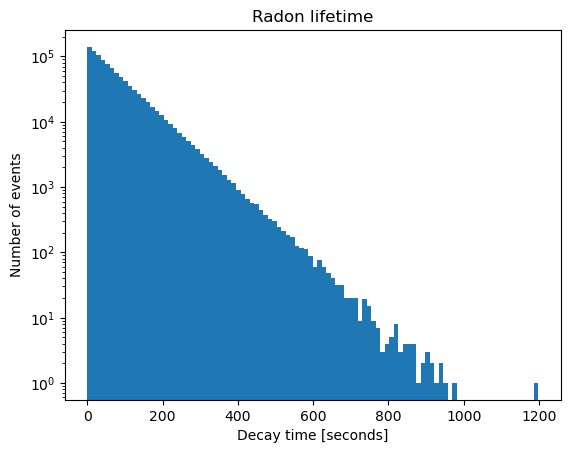

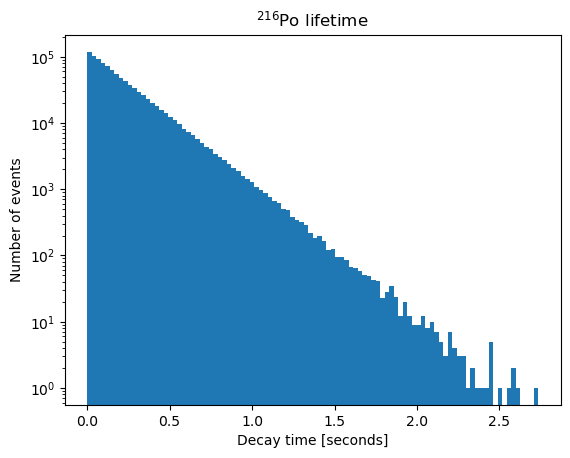

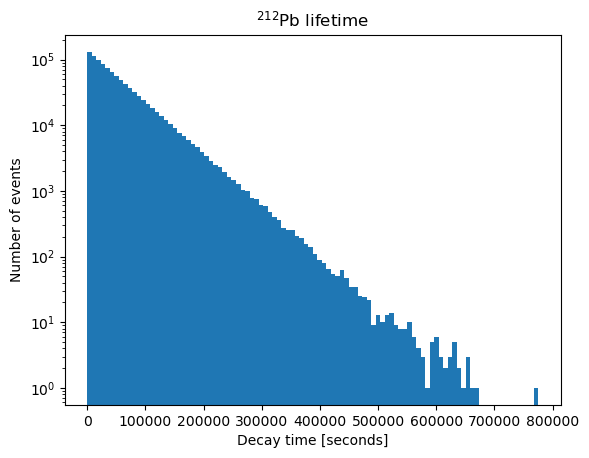

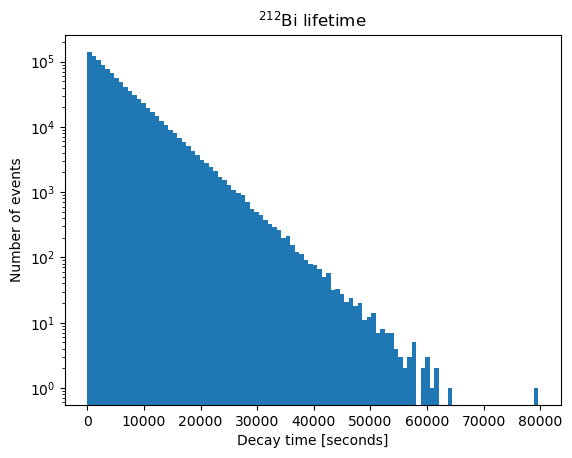

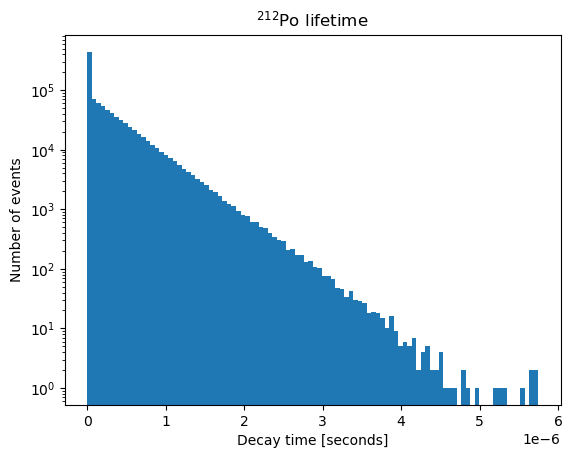

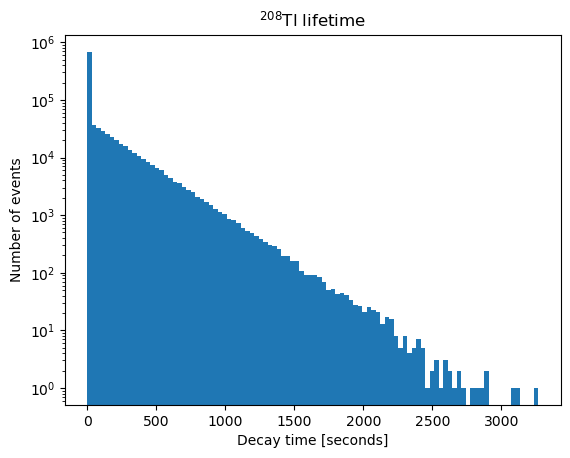

In [19]:
radon=rng.exponential(1/lambdaRn,1000000)
scalePo216=0.15/np.log(2)
po216=rng.exponential(scalePo216,1000000)
scalePb212=10.6*3600/np.log(2)
pb212=rng.exponential(scalePb212,1000000)
scaleBi212=60.6*60/np.log(2)
bi212=rng.exponential(scaleBi212,1000000)
# here we generate a branch variable, which decides which one of two ways to go
branch=rng.random(1000000)
scalePo212=299e-9/np.log(2)
po212=rng.exponential(scalePo212,1000000)# generate all million to begin with
po212[np.where(branch>=0.64)]=0
po212[(branch>=0.64).nonzero()]=0
scaleTl208=3.05*60/np.log(2)
tl208=rng.exponential(scaleTl208,1000000)# generate all million to begin with
tl208[np.where(branch<=0.64)]=0
tl208[(branch<=0.64).nonzero()]=0

for i in range(10):
    print(f'Atom {i}: Radon {radon[i]:8.4f} s, Po-216 {po216[i]:6.4f} s, Pb-212 {pb212[i]:10.4f} s, Bi-212 {bi212[i]:10.4f}s, Po-212 {po212[i]:.4}s, Tl-208 {tl208[i]:10.4f}s')

#double check the distributions by plotting them.
plt.figure()
plt.hist(radon,100)
plt.title('Radon lifetime')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.yscale('log')
plt.show()

plt.figure()
plt.hist(po216,100)
plt.title(r'$^{216}$Po lifetime')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.yscale('log')
plt.show()

plt.figure()
plt.hist(pb212,100)
plt.title(r'$^{212}$Pb lifetime')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.yscale('log')
plt.show()

plt.figure()
plt.hist(bi212,100)
plt.title(r'$^{212}$Bi lifetime')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.yscale('log')
plt.show()

plt.figure()
plt.hist(po212,100)
plt.title(r'$^{212}$Po lifetime')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.yscale('log')
plt.show()

plt.figure()
plt.hist(tl208,100)
plt.title(r'$^{208}$Tl lifetime')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.yscale('log')
plt.show()



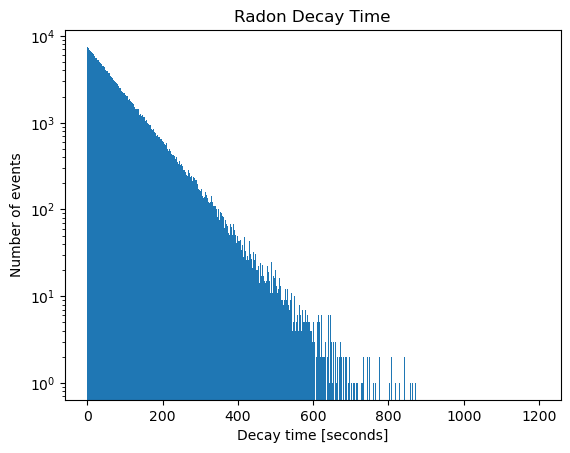

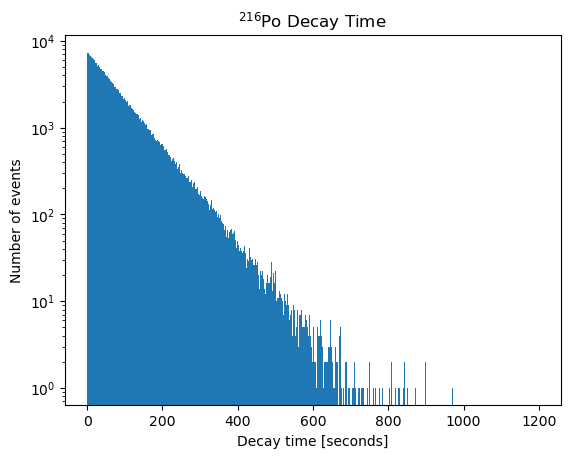

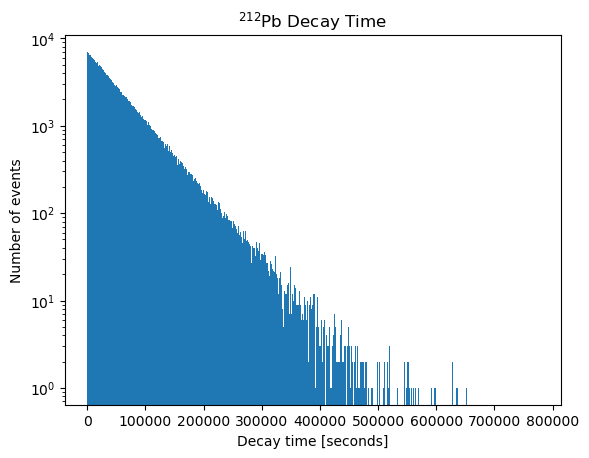

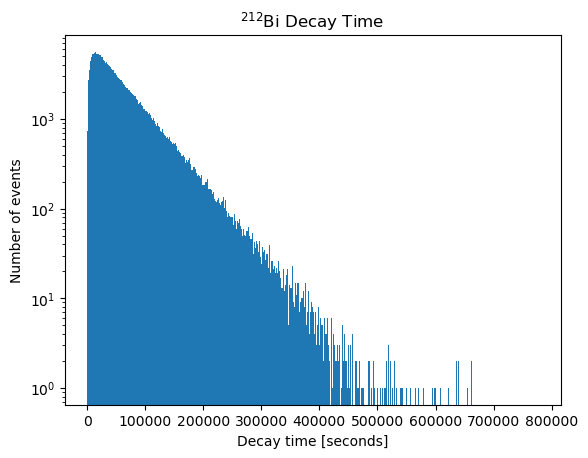

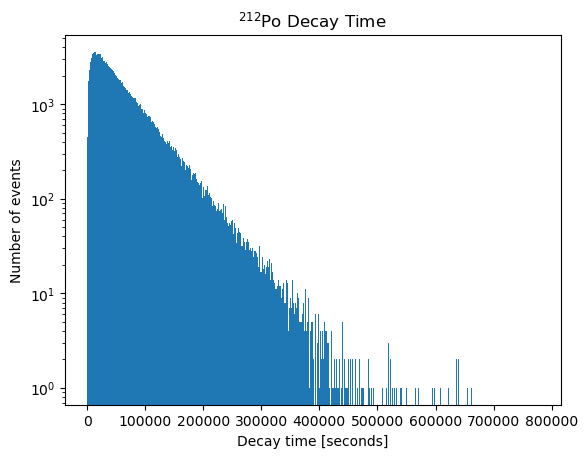

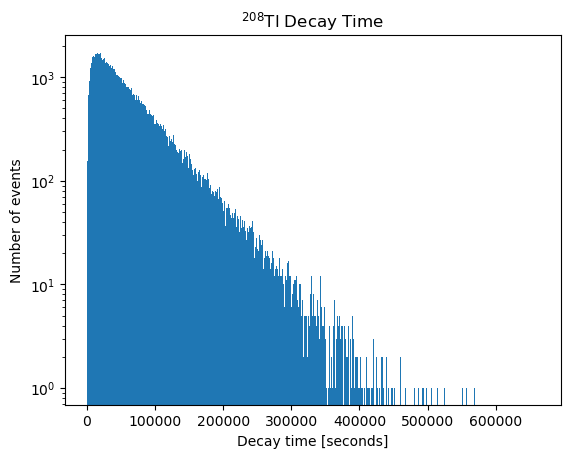

In [20]:
radonDecayTime=radon
po216DecayTime=radon+po216
pb212DecayTime=po216DecayTime+pb212
bi212DecayTime=pb212DecayTime+bi212
po212DecayTime=(bi212DecayTime+po212)[np.where(po212!=0)]  # the bracket removes 0's for events which went to Tl20
tl208DecayTime=(bi212DecayTime+tl208)[np.where(tl208!=0)]  # this includes 0's for events which went to Po212
bipoTime=bi212DecayTime[np.where(po212!=0)]
bitlTime=bi212DecayTime[np.where(tl208!=0)]

plt.figure()
plt.hist(radonDecayTime,2000)
plt.title('Radon Decay Time')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.yscale('log')
plt.show()

plt.figure()
plt.hist(po216DecayTime,2000)
plt.title(r'$^{216}$Po Decay Time')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.yscale('log')
plt.show()

plt.figure()
plt.hist(pb212DecayTime,2000)
plt.title(r'$^{212}$Pb Decay Time')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.yscale('log')
plt.show()

plt.figure()
plt.hist(bi212DecayTime,2000)
plt.title(r'$^{212}$Bi Decay Time')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.yscale('log')
plt.show()

plt.figure()
plt.hist(po212DecayTime,2000)
plt.title(r'$^{212}$Po Decay Time')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.yscale('log')
plt.show()

plt.figure()
plt.hist(tl208DecayTime,2000)
plt.title(r'$^{208}$Tl Decay Time')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of events')
plt.yscale('log')
plt.show()


### Validation:  Runge Kutta Integration of Decay Curve

For a decay chain with elements 1, 2 ...N and decay rates $\lambda_1, \lambda_2, ... \lambda_N$ we have the equations:
\begin{equation}dN_1=-\lambda_1 N_1 dt\end{equation}
\begin{equation}dN_2=\lambda_1 N_1 dt-\lambda_2 N_2 dt \end{equation}

etc.  

We can readily build a decay chain model that we can pass into Runge-Kutta integration.  We will find that if we use the standard solve_ivp with the "RK45" solver, that the integrator doesn't work.  We need to change to a "stiff" equation solver, such as "BDF".  See help(solve_ivp) for the details.  The problem comes about because the time scales are very different- from 300 ns to 10 hours.  

In [21]:
from scipy.integrate import solve_ivp

def decay(t,y):
    nRn,n216Po,n212Pb,n212Bi,n212Po,n208Tl=y
    dydt=( -lambdaRn*nRn, lambdaRn*nRn-n216Po/scalePo216,        
          n216Po/scalePo216-n212Pb/scalePb212,
          n212Pb/scalePb212-n212Bi/scaleBi212,
          0.64*n212Bi/scaleBi212-n212Po/scalePo212,
          0.36*n212Bi/scaleBi212-n208Tl/scaleTl208) #remember "scale=1/lambda"
    return dydt

def decayZoom(t,y):
    nRn,n216Po,n212Pb=y
    dydt=( -lambdaRn*nRn, lambdaRn*nRn-n216Po/scalePo216,        
          n216Po/scalePo216-n212Pb/scalePb212) #remember "scale=1/lambda"
    return dydt

t=np.linspace(0,800000,1000)
y0=np.array([1e6,0,0,0,0,0])
solution=solve_ivp(decay,(0,t[-1]),y0,method='BDF',t_eval=t)
print(solution)

y0zoom=([1e6,0,0])
tzoom=np.linspace(0,2000,100)  #intherwise there are too few bins to see the initial radon decays
solutionZoom=solve_ivp(decayZoom,(0,2000),y0zoom,t_eval=tzoom)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  8.008e+02 ...  7.992e+05  8.000e+05]
        y: [[ 1.000e+06  4.134e+01 ...  6.710e-36  8.432e-37]
            [ 0.000e+00  1.130e-01 ...  1.835e-38  2.306e-39]
            ...
            [ 0.000e+00  6.393e-07 ...  2.755e-12  2.715e-12]
            [ 0.000e+00  1.474e+02 ...  9.529e-04  9.392e-04]]
      sol: None
 t_events: None
 y_events: None
     nfev: 424
     njev: 2
      nlu: 47


There is a subtlety here- when we plotted MC we plotted the time of the decay- so we ended up with a plot of decay rates.  When we solved the ODE's we solved for the number of atoms at any given time.  To compare the plots we want to convert them both to the same quantity.  We will define a function which converts the MC into a total number of atoms.

In [22]:
def N(t, t1, t2):
    '''For an array t of times, and t1 birth times and t2 decay times for 
    a given species calculates the number of entries for which t1<t and t<t2-- ie.  the number of atoms that exist at time t'''
    if np.isscalar(t):
        n=np.where(t1<t)[0].size-np.where(t>t2)[0].size
    else:
        n=np.empty_like(t)
        for i in np.arange(0,len(t)):
            tt=t[i]
            n[i]=np.where(t1<tt)[0].size-np.where(tt>t2)[0].size
    return n


In [23]:
t1=radonDecayTime
t2=po216DecayTime
print(t1,t2)
test=N(957.222,radonDecayTime,po216DecayTime)
print(radonDecayTime[np.where(900<=radonDecayTime)])#+po216DecayTime)[0].size
print(po216DecayTime[np.where(900<=po216DecayTime)])#+po216DecayTime)[0].size
print(test)

[341.3554086   60.02713475  93.87133871 ...  56.82476807  37.82825636
  16.74846775] [341.93006023  60.10356111  93.91615428 ...  56.86374173  37.95574169
  16.91013551]
[ 918.11694488  955.95040105  970.60551315  932.57824108  902.113717
  916.02424972  942.49579714 1197.34085636  935.98481845]
[ 918.29713836  956.12577779  970.74170958  932.58893494  902.54697539
  916.25252727  942.51999747 1197.93085928  936.25513615]
0


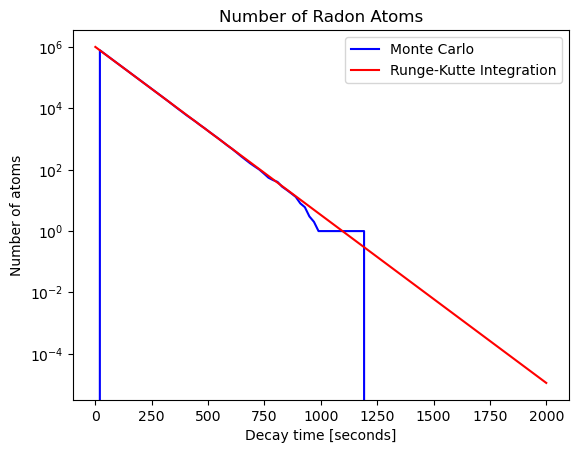

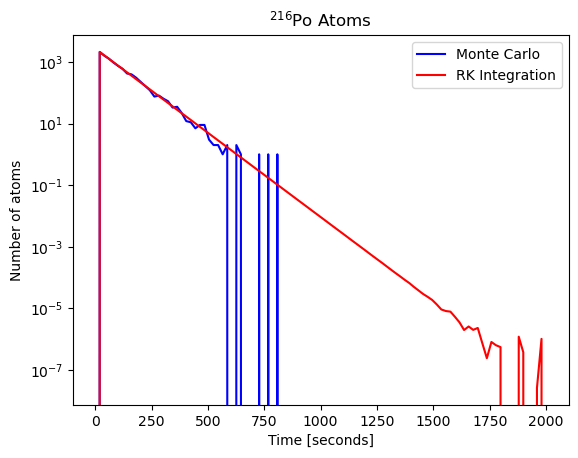

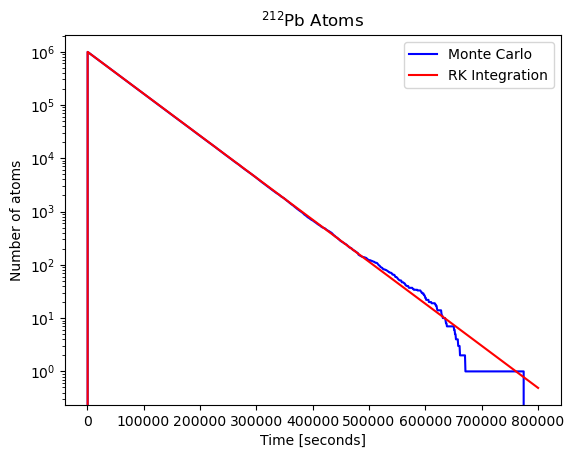

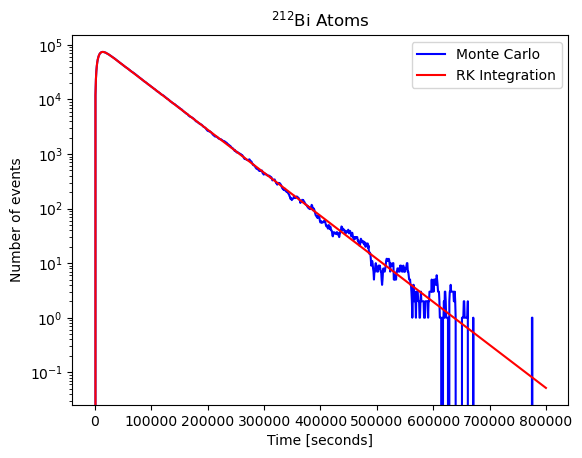

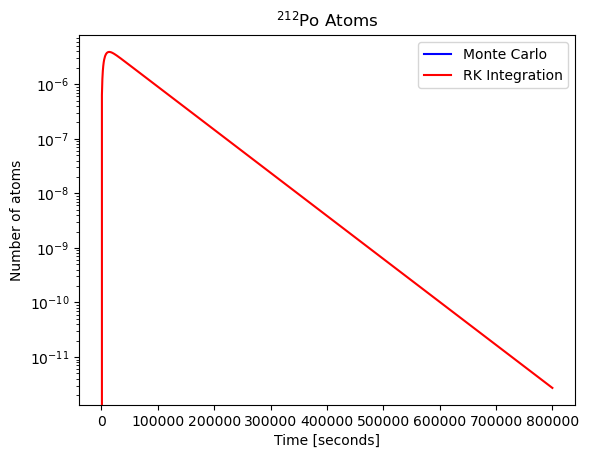

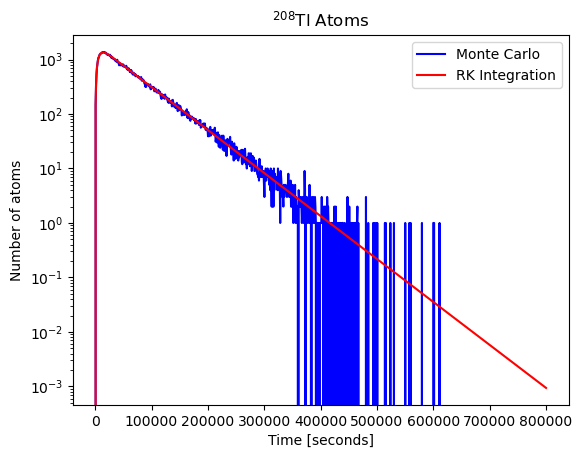

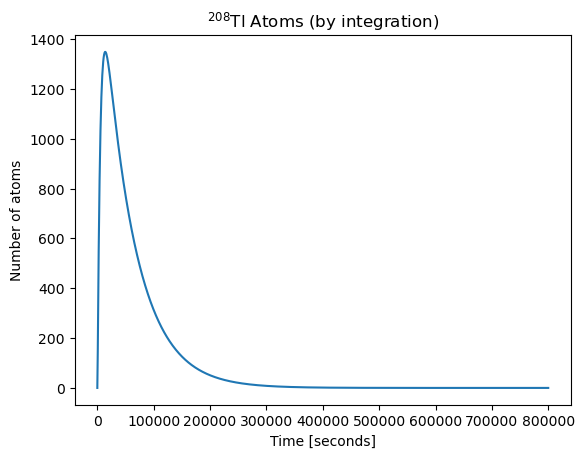

In [24]:
tzero=np.zeros(len(radonDecayTime))
plt.figure()
#plt.hist(radonDecayTime,1000)
plt.plot(tzoom,N(tzoom,tzero,radonDecayTime),'b',label='Monte Carlo')
plt.plot(tzoom,solutionZoom.y[0,:],'r',label='Runge-Kutte Integration')
#print(N(t[range],0,radonDecayTime))
plt.title('Number of Radon Atoms')
plt.xlabel('Decay time [seconds]')
plt.ylabel('Number of atoms')
plt.yscale('log')
plt.legend()
plt.show()

plt.figure()
plt.plot(tzoom,N(tzoom,radonDecayTime,po216DecayTime),'b',label='Monte Carlo')
plt.plot(tzoom,solutionZoom.y[1,:],'r',label='RK Integration')
plt.title(r'$^{216}$Po Atoms')
plt.xlabel('Time [seconds]')
plt.ylabel('Number of atoms')
plt.yscale('log')
plt.legend()
plt.show()

plt.figure()
plt.plot(t,N(t,po216DecayTime,pb212DecayTime),'b',label='Monte Carlo')
plt.plot(t,solution.y[2,:],'r',label='RK Integration')
plt.legend()
plt.title(r'$^{212}$Pb Atoms')
plt.xlabel('Time [seconds]')
plt.ylabel('Number of atoms')
plt.yscale('log')
plt.show()

plt.figure()
plt.plot(t,N(t,pb212DecayTime,bi212DecayTime),'b',label='Monte Carlo')
plt.plot(t,solution.y[3,:],'r',label='RK Integration')
plt.legend()
plt.title(r'$^{212}$Bi Atoms')
plt.xlabel('Time [seconds]')
plt.ylabel('Number of events')
plt.yscale('log')
plt.show()

plt.figure()
plt.plot(t,N(t,bipoTime,po212DecayTime),'b',label='Monte Carlo')
plt.plot(t,solution.y[4,:],'r',label='RK Integration')
plt.legend()
plt.title(r'$^{212}$Po Atoms')
plt.xlabel('Time [seconds]')
plt.ylabel('Number of atoms')
plt.yscale('log')
plt.show()

plt.figure()
plt.plot(t,N(t,bitlTime,tl208DecayTime),'b',label='Monte Carlo')
plt.plot(t,solution.y[5,:],'r',label='RK Integration')
plt.legend()
plt.title(r'$^{208}$Tl Atoms')
plt.xlabel('Time [seconds]')
plt.ylabel('Number of atoms')
plt.yscale('log')
plt.show()


plt.figure()
plt.plot(t,solution.y[5,:])
plt.title(r'$^{208}$Tl Atoms (by integration)')
plt.xlabel('Time [seconds]')
plt.ylabel('Number of atoms')
plt.show()

In [25]:
solution.y.shape

(6, 1000)

Does the plot for $^{212}$Po make sense?



### Stochastic modelling

We see that the Runge-Kutta integration works well when the number of atoms are large.  But there are a set of questions we can ask that depend upon the *random* nature of the fundamental process in a Monte Carlo calculation, but that we can't answer with just the probability distribution.  

So, for instance, we can make the distribution of the time of the last decay.  How do we do that?  We do the experiment N times (inside the computer), and make a histogram of when the last atom decays.  To make this take a reasonable amount of time, let's run the MC experiment 1000 times, starting with 10000 Radon atoms and seeing when the last one decays.  

In [26]:
nAtoms=10000
nExperiments=10000
tdist=np.zeros(nExperiments)
for experimentIndex in np.arange(0,nExperiments):
    radon=rng.exponential(1/lambdaRn,nAtoms)
    scalePo216=0.15/np.log(2)
    po216=rng.exponential(scalePo216,nAtoms)
    scalePb212=10.6*3600/np.log(2)
    pb212=rng.exponential(scalePb212,nAtoms)
    scaleBi212=60.6*60/np.log(2)
    bi212=rng.exponential(scaleBi212,nAtoms)
    # here we generate a branch variable, which decides which one of two ways to go
    branch=rng.random(nAtoms)
    scalePo212=299e-9/np.log(2)
    po212=rng.exponential(scalePo212,nAtoms)# generate all to begin with
    po212[np.where(branch>=0.64)]=0
    scaleTl208=3.05*60/np.log(2)
    tl208=rng.exponential(scaleTl208,nAtoms)# generate all to begin with
    tl208[np.where(branch<=0.64)]=0

    t=radon+po216+pb212+bi212+po212+tl208
    tdist[experimentIndex]=np.max(t)
    if experimentIndex%500 == 0:
        print(experimentIndex)
    
plt.figure()
plt.hist(tdist,100)
plt.title('Distribution of decay time of final radioactive atom')
plt.xlabel('Time[s]')
plt.ylabel('Number')
plt.yscale('log')

0
500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500


Notice that the distribution is nothing like a gaussian distribution- it is asymmetric and extends much further to long times than to short times.

What is the probability that the last radon decays more than a million seconds after the injection?  

Of course there are many similar questions we can answer with "multiple experiments". 


### Frequentist and Bayesian Statistics

With the wide spread use of MC, and the ability to generate multiple data sets, we can answer the question:  if the distributions of parameters are known, what are the distributions of *measurements*?  This is the central question of *frequentist* statistics, and can be answered rigorously with MC calculations.  (cf.  John Bahcall's 1000 solar models)

Frequentists talk about "distributions of measurements".  Bayesians talk about "probabilities of parameters".  Both are correct but reveal different aspects of measurements.  So for instance-- one knows a mass can't be negative (to start with).  But an experiment that has a distribution can result in a *mass measurement* that is negative.  

Independent of philosophy, MC techniques like this allow one to probe complex distributions and make inferences about measurements without assumptions of normal distributions, or high statistics, etc. etc.  

# Statistical Distributions: Poisson Distribution

The Poisson distribution applies for *independent* events with a constant probability.  It gives us the probability
that we observe *n* events in when we expect $\bar{x}$ events in a given time interval, and is derived to be $$P(n)= \frac{\bar{x}^n e^{-\bar{x}}}{n!}.$$  If n becomes large it approaches the normal (also called the Gaussian) distribution:
$$P(n)=\frac{1}{\sqrt{2\pi}\sigma}\exp\left(-\frac{(n-\bar{x})^2}{2\sigma^2}\right)$$ with $\sigma = \sqrt{N}.$

We plot the Poisson distribution for a $\bar{x}=0.01, 0.1, 1, 2, 3, 5$ and a second plot for 10,20,40,100.

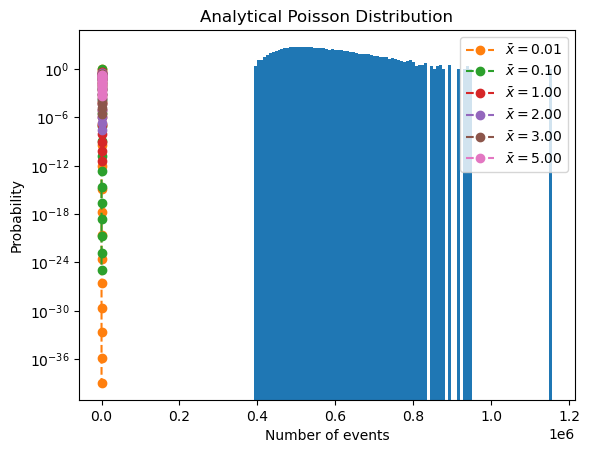

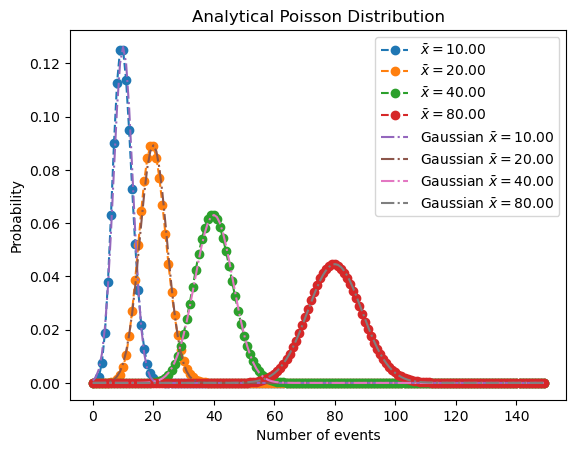

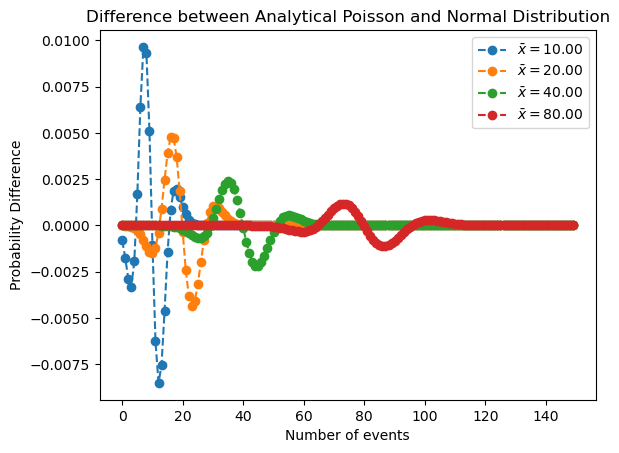

In [27]:
import math
def poisson(n, xbar):
    return xbar**n*math.exp(-xbar)/math.factorial(n)
xlist=(0.01,0.1,1,2,3,5)
nlist=range(15)
for xb in xlist:
    plt.plot(nlist,[poisson(n,xb) for n in nlist],'o',ls='--',label=r'$\bar{x}=$'+f'{xb:.2f}')
plt.legend()
plt.title("Analytical Poisson Distribution")
plt.xlabel("Number of events")
plt.ylabel("Probability")
plt.show()

def gaus(n,xbar):
    sigma=math.sqrt(xbar)
    return 1/math.sqrt(2*math.pi)/sigma*math.exp(-((n-xbar)/sigma)**2/2)
xlist=(10,20,40,80)
nlist=range(150)
for xb in xlist:
    plt.plot(nlist,[poisson(n,xb) for n in nlist],'o',ls='--',label=r'$\bar{x}=$'+f'{xb:.2f}')
for xb in xlist:
    plt.plot(nlist,[gaus(n,xb) for n in nlist],ls='-.',label=r'Gaussian $\bar{x}=$'+f'{xb:.2f}')

plt.legend()
plt.title("Analytical Poisson Distribution")
plt.xlabel("Number of events")
plt.ylabel("Probability")
plt.show()

for xb in xlist:
    plt.plot(nlist,[poisson(n,xb)-gaus(n,xb) for n in nlist],'o',ls='--',label=r'$\bar{x}=$'+f'{xb:.2f}')

plt.legend()
plt.title("Difference between Analytical Poisson and Normal Distribution")
plt.xlabel("Number of events")
plt.ylabel("Probability Difference")
plt.show()

Now let's Monte Carlo these.  What we will do is generate a large number of "events."  We want to generate a constant rate, so for each event we will throw N2 random numbers between 0 and 1, and histogram the number of those random numbers (which are independent occurances) which have probability below 0.01/N2, 0.1/N2, ... and see if our MC distribution matches the analytic distributions.



Start with N2=2000 and then repeat when N2=200.

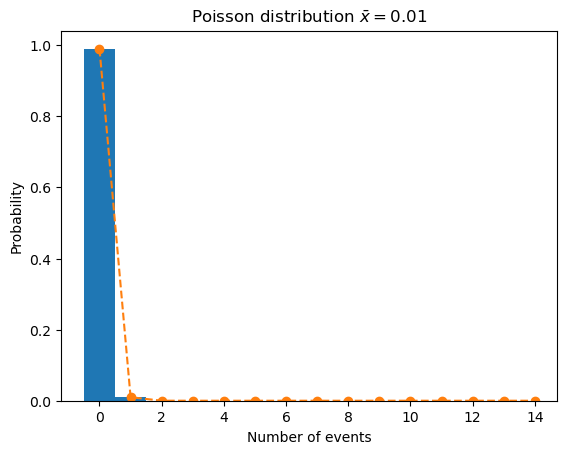

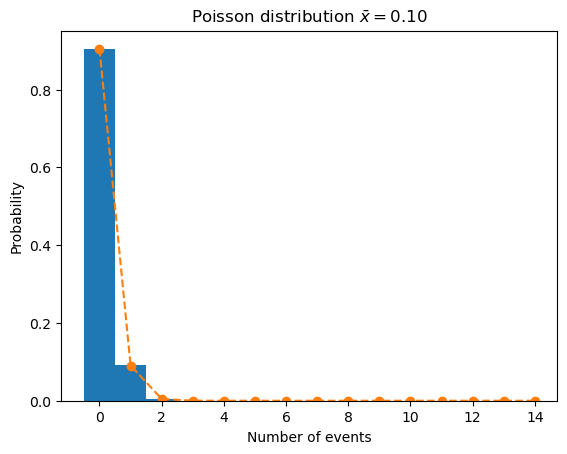

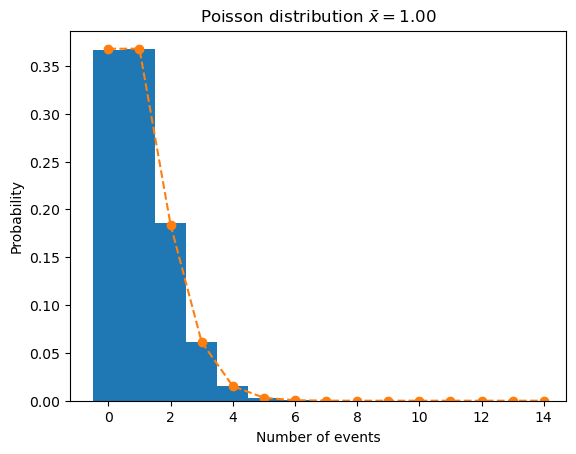

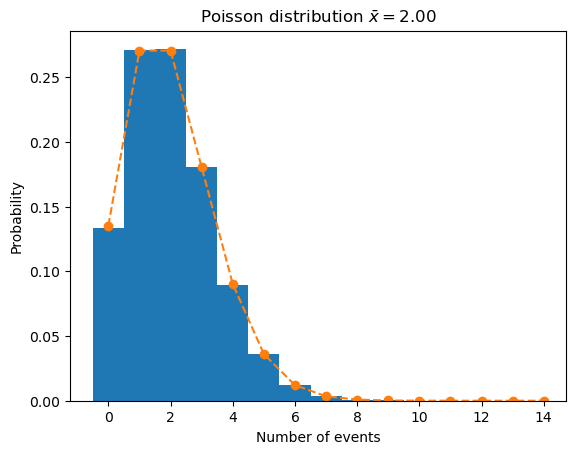

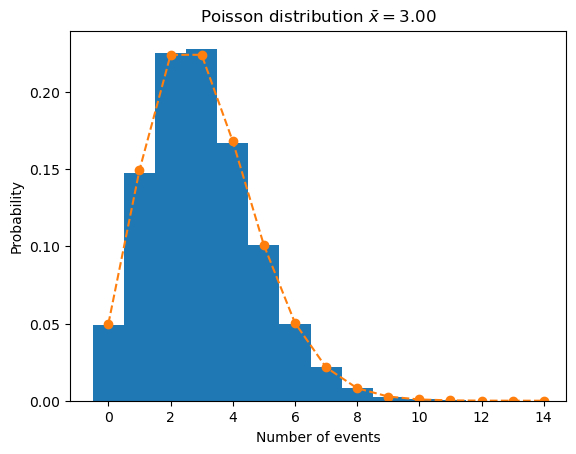

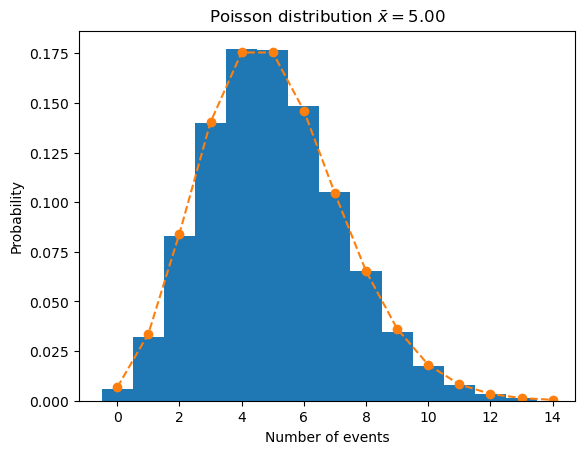

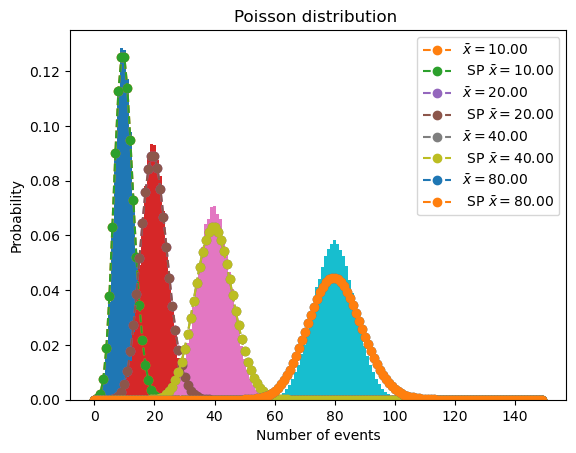

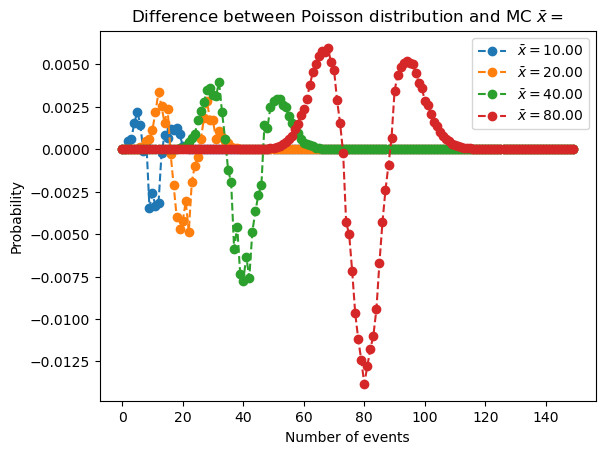

In [28]:
np01=[]
np1=[]
n1=[]
n2=[]
n3=[]
n5=[]
n10=[]
n20=[]
n40=[]
n80=[]
N=100000
N2=200
for i in range(N):
    l=rng.uniform(size=N2)
    np01.append(np.asarray(l<(0.01/N2)).nonzero()[0].size)
    np1.append(np.asarray(l<(0.1/N2)).nonzero()[0].size)
    n1.append(np.asarray(l<(1/N2)).nonzero()[0].size)
    n2.append(np.asarray(l<(2/N2)).nonzero()[0].size)
    n3.append(np.asarray(l<(3/N2)).nonzero()[0].size)
    n5.append(np.asarray(l<(5/N2)).nonzero()[0].size)
    n10.append(np.asarray(l<(10/N2)).nonzero()[0].size)
    n20.append(np.asarray(l<(20/N2)).nonzero()[0].size)
    n40.append(np.asarray(l<(40/N2)).nonzero()[0].size)
    n80.append(np.asarray(l<(80/N2)).nonzero()[0].size)

l1=[np01,np1,n1,n2,n3,n5]
l2=[n10,n20,n40,n80]
xlist=(0.01,0.1,1,2,3,5)
nlist=range(15)
for i,l in enumerate(l1):
    l=np.array(l)
    plt.hist(l,bins=14,range=[-0.5,13.5],weights=np.ones(N)/N)
    plt.plot(nlist,[poisson(n,xlist[i]) for n in nlist],'o',ls='--',label=r'$\bar{x}=$'+f'{xlist[i]:.2f}')
    plt.title("Poisson distribution "+r'$\bar{x}=$'+f'{xlist[i]:.2f}')
    plt.xlabel("Number of events")
    plt.ylabel("Probability")
    plt.show()

xlist=(10,20,40,80)
nlist=range(150)
from scipy.stats import poisson as scpoisson
for i,l in enumerate(l2):
    l=np.array(l)
    plt.hist(l,bins=150,range=[-0.5,149.5],weights=np.ones(N)/N)
    plt.plot(nlist,[poisson(n,xlist[i]) for n in nlist],'o',ls='--',label=r'$\bar{x}=$'+f'{xlist[i]:.2f}')
    plt.plot(nlist,[scpoisson.pmf(n,xlist[i]) for n in nlist],'o',ls='--',label=r' SP $\bar{x}=$'+f'{xlist[i]:.2f}')

plt.title("Poisson distribution ")
plt.xlabel("Number of events")
plt.ylabel("Probability")
plt.legend()
plt.show()

for i,l in enumerate(l2):
    l=np.array(l)
    h=np.histogram(l,bins=150,range=[-0.5,149.5],weights=np.ones(N)/N)
    plt.plot(nlist,[poisson(n,xlist[i]) -h[0][n] for n in nlist],'o',ls='--',label=r'$\bar{x}=$'+f'{xlist[i]:.2f}')
#    plt.plot(nlist,[scpoisson.pmf(n,xlist[i]) for n in nlist],'o',ls='--',label=r' SP $\bar{x}=$'+f'{xlist[i]:.2f}')
plt.title("Difference between Poisson distribution and MC "+r'$\bar{x}=$')
plt.xlabel("Number of events")
plt.ylabel("Probability")

plt.legend()
plt.show()
    

What is the reason the distribution gets narrower when N=200 compared to N=2000?  

It comes down to the fact that events are not *independent* when there are a fixed number of events we are picking from.  If there are N2 events, and we have a probability $p$ that the event is included, we actually have the *Binomial Distribution*, which is the distribution you get for the number of heads, $m$ when a coin is tossed $N$ times:

$$P(m)=\frac {N!}{m! (N-m)!}p^m (1-p)^{N-m}$$ 

The Poisson distribution is based on an average *rate* that is fixed, while the Binomial distribution is based on a fixed number of trials.  When the probability $p$ is small, they approach one another.  

We write and plot the binomial distribution:

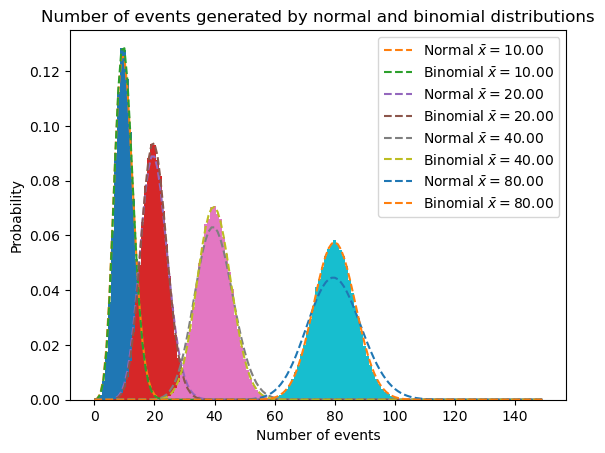

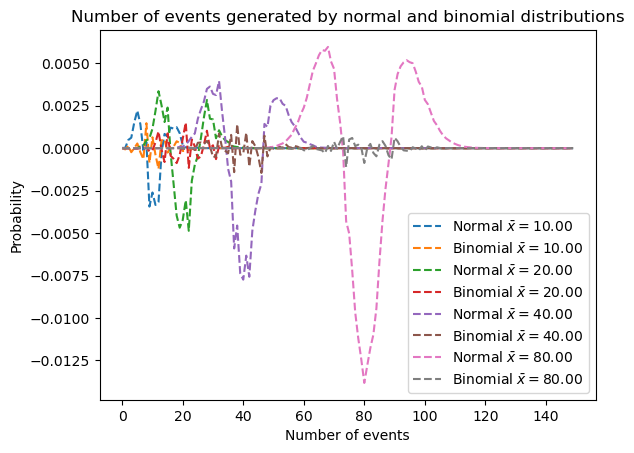

In [29]:
def binomial(p,N,m):
    return math.comb(N,m)*p**m *(1-p)**(N-m)


xlist=(10,20,40,80)
nlist=range(150)
for i,l in enumerate(l2):
    l=np.array(l)
    plt.hist(l,bins=150,range=[-0.5,149.5],weights=np.ones(N)/N)
    plt.plot(nlist,[poisson(n,xlist[i]) for n in nlist],ls='--',label=r'Normal $\bar{x}=$'+f'{xlist[i]:.2f}')
    p=xlist[i]/N2
    plt.plot(nlist,[binomial(p,N2,n) for n in nlist],ls='--',label=r'Binomial $\bar{x}=$'+f'{xlist[i]:.2f}')
plt.title("Number of events generated by normal and binomial distributions")
plt.xlabel("Number of events")
plt.ylabel("Probability")
plt.legend()
plt.show()

for i,l in enumerate(l2):
    l=np.array(l)
    h=np.histogram(l,bins=150,range=[-0.5,149.5],weights=np.ones(N)/N)
    plt.plot(nlist,[poisson(n,xlist[i])-h[0][n] for n in nlist],ls='--',label=r'Normal $\bar{x}=$'+f'{xlist[i]:.2f}')
    p=xlist[i]/N2
    plt.plot(nlist,[binomial(p,N2,n)-h[0][n] for n in nlist],ls='--',label=r'Binomial $\bar{x}=$'+f'{xlist[i]:.2f}')
plt.title("Number of events generated by normal and binomial distributions")
plt.xlabel("Number of events")
plt.ylabel("Probability")
plt.legend()
plt.show()

Our technique of generating N2 random numbers, and picking a fixed probability is actually generating a true binomial distribution!
How do we generate a constant rate?  

We go back to 
\begin{equation}dP(t+dt)=P(t)(1-\lambda dt)\rightarrow \frac{dP}{dt}=-P\lambda\rightarrow P=P_0 e^{-\lambda t}\end{equation}

If events happen at a rate $1/\lambda$ the time to the next event follows an exponential distribution. Then the procedure becomes:
 1. For a given rate, generate the time to the next event delta T
 2. Keep track of the total time, until you get to $N\lambda$-- the average time for $N$ events.
 3. Count the number of events that you have generated


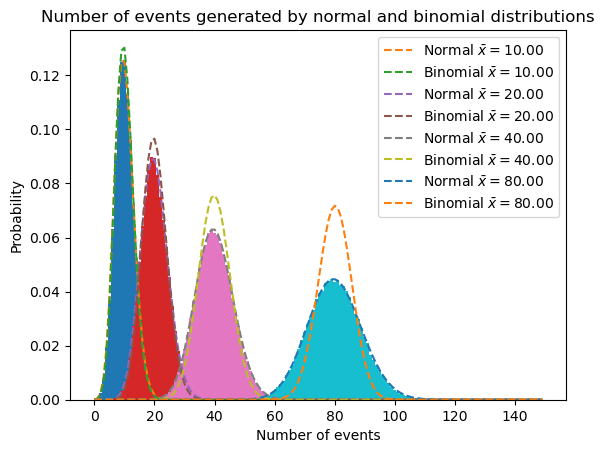

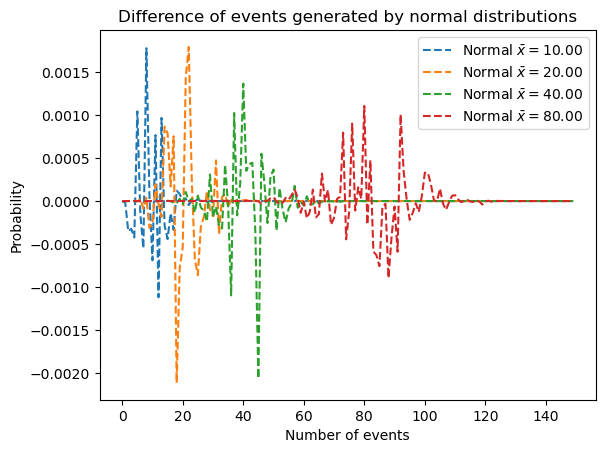

In [30]:
N2=130
xlist=(10,20,40,80)
l2=[]
for rate in xlist:
    l=[]
    for i in range(N):
        lsum=np.cumsum(rng.exponential(1.0/rate,size=N2))
        l.append(np.asarray(lsum>1.0).nonzero()[0][0])
    l2.append(l)
nlist=range(150)
for i,l in enumerate(l2):
    l=np.array(l)
    plt.hist(l,bins=150,range=[-0.5,149.5],weights=np.ones(N)/N)
    plt.plot(nlist,[poisson(n,xlist[i]) for n in nlist],ls='--',label=r'Normal $\bar{x}=$'+f'{xlist[i]:.2f}')
    p=xlist[i]/N2
    plt.plot(nlist,[binomial(p,N2,n) for n in nlist],ls='--',label=r'Binomial $\bar{x}=$'+f'{xlist[i]:.2f}')
plt.title("Number of events generated by normal and binomial distributions")
plt.xlabel("Number of events")
plt.ylabel("Probability")
plt.legend()

plt.show()

for i,l in enumerate(l2):
    l=np.array(l)
    h=np.histogram(l,bins=150,range=[-0.5,149.5],weights=np.ones(N)/N)
    plt.plot(nlist,[poisson(n,xlist[i])-h[0][n] for n in nlist],ls='--',label=r'Normal $\bar{x}=$'+f'{xlist[i]:.2f}')
    p=xlist[i]/N2
#    plt.plot(nlist,[binomial(p,N2,n)-h[0][n] for n in nlist],ls='--',label=r'Binomial $\bar{x}=$'+f'{xlist[i]:.2f}')
plt.title("Difference of events generated by normal distributions")
plt.xlabel("Number of events")
plt.legend()
plt.ylabel("Probability")
plt.show()

#  The $\chi^2$ Distribution

When fitting data, you will run into the $\chi^2$ distribution, which is actually just the sum of n normal variables, squared:

$$\chi^2=\sum_{i=0}^{N} \left(\frac{y(x_i)-y_i}{\sigma_i}\right)^2$$

where we have a measured set of values $(x_i,y_i)$, with uncertainty $\sigma_i$ and a model function $y(x)$ that we can use to calculate an "expected" value.

We can model this easily, and compare the "MC" generated distribution with that from the analytical scipy.stats.chi2 function.

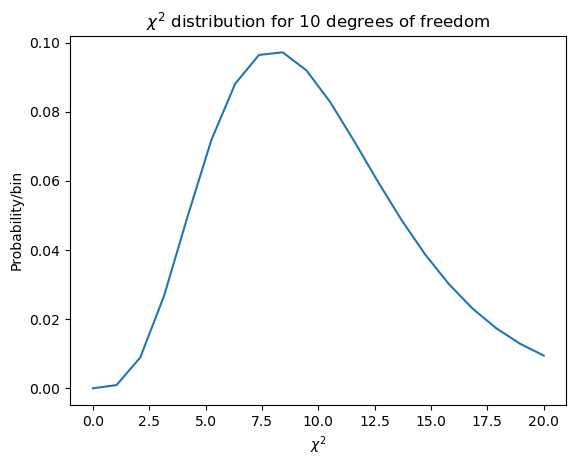

In [31]:
from scipy.stats import chi2
df=10 #number of degrees of freedom=number of data points
nlist=np.linspace(0,20,20)
plt.plot(nlist,[chi2.pdf(n,df) for n in nlist])
plt.title("$\chi^2$ distribution for 10 degrees of freedom")
plt.xlabel("$\chi^2$")
plt.ylabel("Probability/bin")
plt.show()

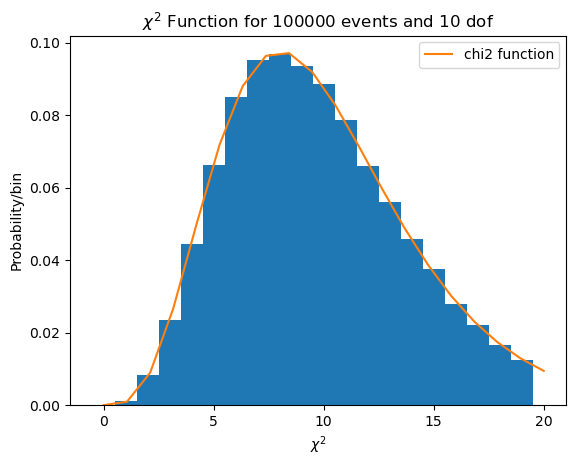

In [32]:
N2=1000
l=[]
df=10
for i in range(N):
    l.append(np.sum(rng.normal(size=df)**2))
plt.hist(l,20,range=(-0.5,19.5),weights=1.0/N*np.ones_like(l))
plt.plot(nlist,[chi2.pdf(n,df) for n in nlist],label='chi2 function')
plt.legend()
plt.title(r'$\chi^2$ Function for '+f'{N} events and 10 dof')
plt.xlabel(r'$\chi^2$')
plt.ylabel('Probability/bin')
plt.show()

We are usually interested in the confidence levels- ie. the $\chi^2$ which cut 5% of experiments from the top and bottom (the so-called 90% confidence levels).  One can get that from the MC, but also using the chi2 function.  Just reading from the graph, we see that 90% of experiments with 10 degrees of freedom should have a $3.8<\chi^2<18.$


In [33]:
plt.plot(nlist,[chi2.cdf(x,10) for x in nlist])
plt.plot([0,20],[0.05,0.05],'--')
plt.plot([0,20],[0.95,0.95],'--')
plt.grid()